## 1. Imports

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve, r2_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import joblib

# XGBoost is the intended production model (see requirements.txt). We import it
# defensively: some environments (e.g. offline sandboxes) may not have it
# installed, in which case we fall back to sklearn's HistGradientBoostingClassifier,
# which uses the same core idea (histogram-based gradient boosting) so the rest of
# the notebook (tuning, evaluation, SHAP) does not need to change.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# SHAP is required for explainability. Same defensive import pattern.
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("XGBoost available:", XGBOOST_AVAILABLE)
print("SHAP available:", SHAP_AVAILABLE)


XGBoost available: True
SHAP available: True


## 2. Load Dataset

In [5]:

df = pd.read_csv("~/Downloads/netflix.csv")
print("Shape:", df.shape)
df.head()


Shape: (5000, 14)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [7]:

df.head(10)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
5,d8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.80,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance
7,02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,14.30,56,Europe,Mobile,8.99,1,Gift Card,1,0.25,Action
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,45,Other,Basic,9.98,10,Asia,Mobile,8.99,0,PayPal,3,0.91,Romance
9,eae6439e-8cdf-4258-ab49-c493925b927a,32,Other,Premium,2.22,34,Europe,TV,17.99,1,Debit Card,1,0.06,Drama


## 3. Dataset Inspection

Basic shape, columns, and dtypes before touching anything.

In [10]:

print("Rows:", df.shape[0], " Columns:", df.shape[1])
print()
print("Columns:", list(df.columns))
print()
df.info()


Rows: 5000  Columns: 14

Columns: ['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_me

## 4. Data Cleaning


### 5. Missing-Value Analysis

In [14]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary)


                        missing_count  missing_pct
customer_id                         0          0.0
age                                 0          0.0
gender                              0          0.0
subscription_type                   0          0.0
watch_hours                         0          0.0
last_login_days                     0          0.0
region                              0          0.0
device                              0          0.0
monthly_fee                         0          0.0
churned                             0          0.0
payment_method                      0          0.0
number_of_profiles                  0          0.0
avg_watch_time_per_day              0          0.0
favorite_genre                      0          0.0


### 6. Duplicate Analysis

In [18]:

full_dupes = df.duplicated().sum()
id_dupes = df["customer_id"].duplicated().sum()
print("Fully duplicated rows:", full_dupes)
print("Duplicated customer_id values:", id_dupes)
print("Unique customer_id count:", df["customer_id"].nunique(), "out of", len(df), "rows")


Fully duplicated rows: 0
Duplicated customer_id values: 0
Unique customer_id count: 5000 out of 5000 rows


### 7. Target Analysis (`churned`)

churned
1    2515
0    2485
Name: count, dtype: int64

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


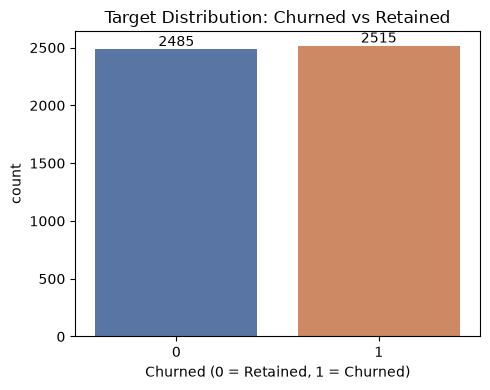

In [22]:

target_counts = df["churned"].value_counts()
target_pct = df["churned"].value_counts(normalize=True) * 100
print(target_counts)
print()
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="churned", data=df, palette=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Target Distribution: Churned vs Retained")
ax.set_xlabel("Churned (0 = Retained, 1 = Churned)")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


### 8. Identifier Analysis

In [26]:

print("customer_id sample values:", df["customer_id"].head(3).tolist())
print("Is customer_id unique for every row?", df["customer_id"].is_unique)


customer_id sample values: ['a9b75100-82a8-427a-a208-72f24052884a', '49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b', '4d71f6ce-fca9-4ff7-8afa-197ac24de14b']
Is customer_id unique for every row? True


### 9. Data Type Analysis

In [30]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("churned")
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_cols.remove("customer_id")

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']
Categorical columns: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']


### 10. Statistical Analysis

In [33]:

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,5000.0,43.84740,15.501128,18.00,30.0000,44.00,58.00,70.00
watch_hours,5000.0,11.64945,12.014654,0.01,3.3375,8.00,16.03,110.40
last_login_days,5000.0,30.08980,17.536078,0.00,15.0000,30.00,45.00,60.00
monthly_fee,5000.0,13.68340,3.692062,8.99,8.9900,13.99,17.99,17.99
number_of_profiles,5000.0,3.02440,1.415841,1.00,2.0000,3.00,4.00,5.00
avg_watch_time_per_day,5000.0,0.87480,2.619824,0.00,0.1100,0.29,0.72,98.42


In [35]:

for c in categorical_cols:
    print(f"--- {c} ({df[c].nunique()} categories) ---")
    print(df[c].value_counts())
    print()


--- gender (3 categories) ---
gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

--- subscription_type (3 categories) ---
subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

--- region (6 categories) ---
region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

--- device (5 categories) ---
device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

--- payment_method (5 categories) ---
payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

--- favorite_genre (7 categories) ---
favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64



### 11. Redundant Features & Leakage Check


In [38]:

print(pd.crosstab(df["subscription_type"], df["monthly_fee"]))
print()
print(df.groupby("subscription_type")["monthly_fee"].agg(["mean", "std", "nunique"]))


monthly_fee        8.99   13.99  17.99
subscription_type                     
Basic               1661      0      0
Premium                0      0   1693
Standard               0   1646      0

                    mean  std  nunique
subscription_type                     
Basic               8.99  0.0        1
Premium            17.99  0.0        1
Standard           13.99  0.0        1


In [41]:

df_model = df.drop(columns=["customer_id", "monthly_fee"])
numeric_cols = [c for c in numeric_cols if c != "monthly_fee"]
print("Columns going into modeling:", df_model.columns.tolist())


Columns going into modeling: ['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']


## 5. Exploratory Data Analysis

### 12a. Numerical Distributions

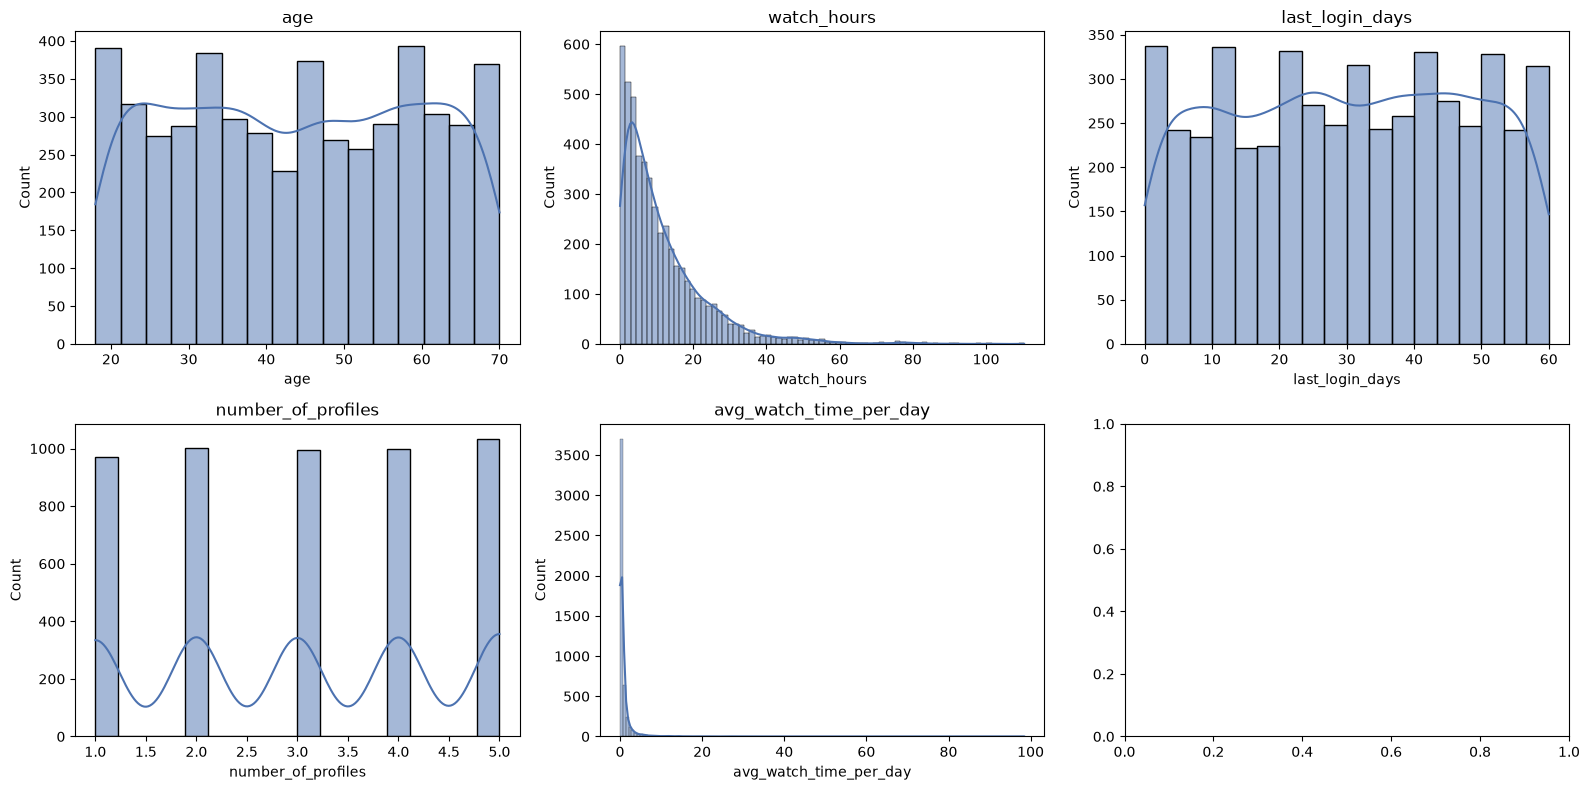

In [45]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df_model[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 12b. Boxplots (spread & candidate outliers)

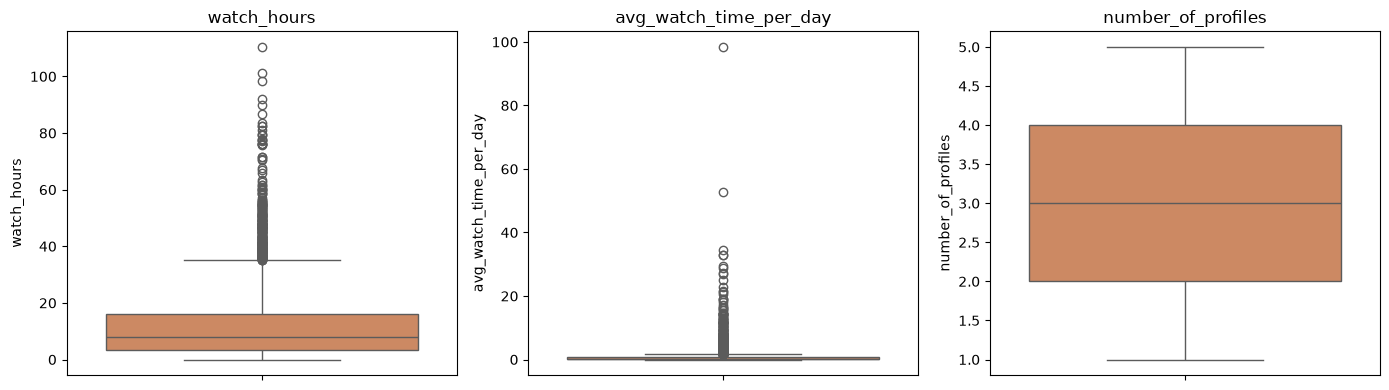

In [49]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["watch_hours", "avg_watch_time_per_day", "number_of_profiles"]):
    sns.boxplot(y=df_model[col], ax=ax, color="#DD8452")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 12c. Categorical Counts

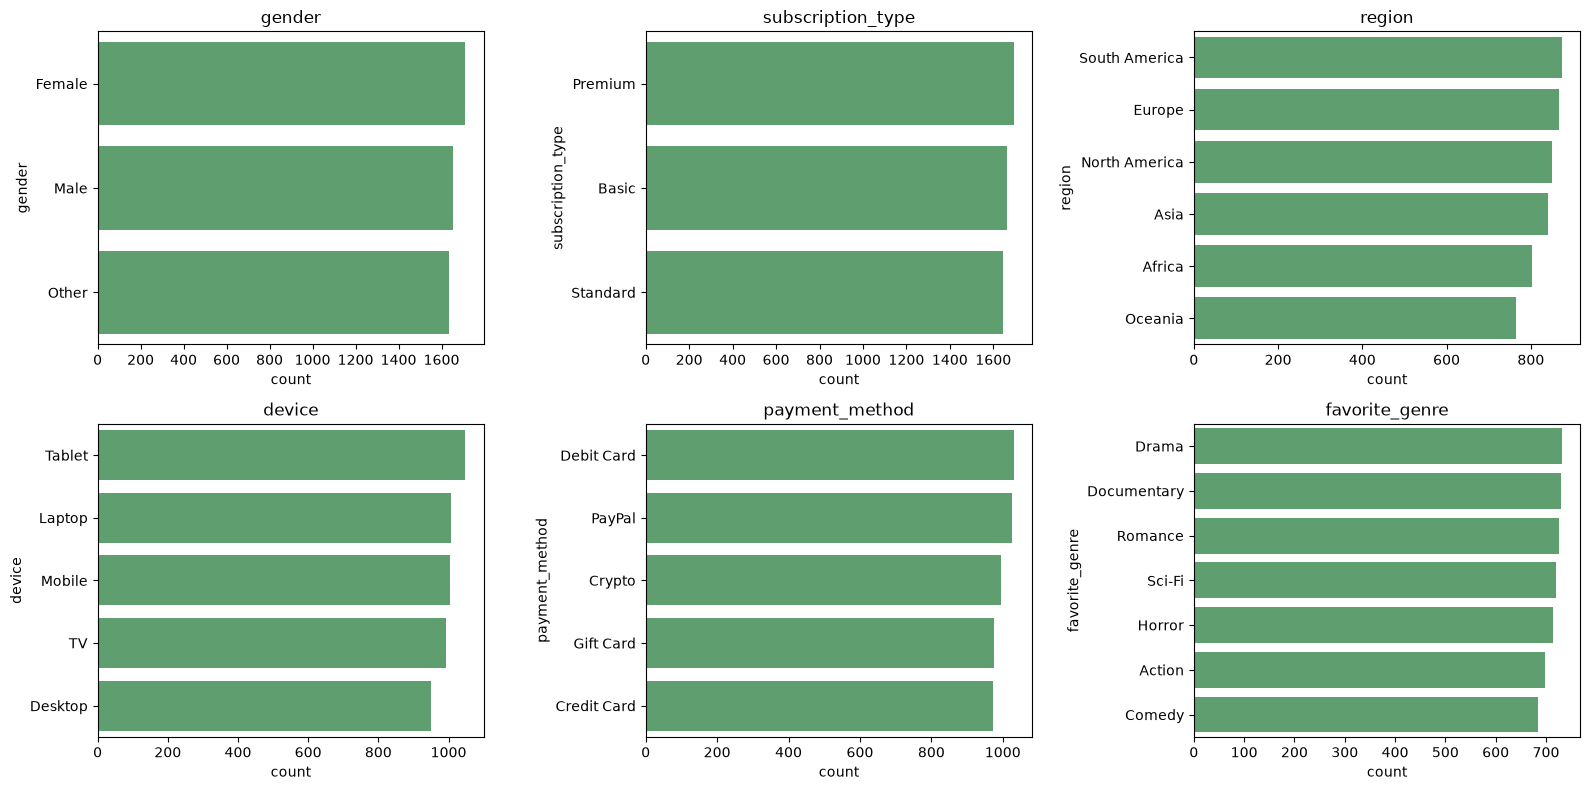

In [52]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, categorical_cols):
    order = df_model[col].value_counts().index
    sns.countplot(y=col, data=df_model, order=order, ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 12d. Correlation Heatmap (numeric features)

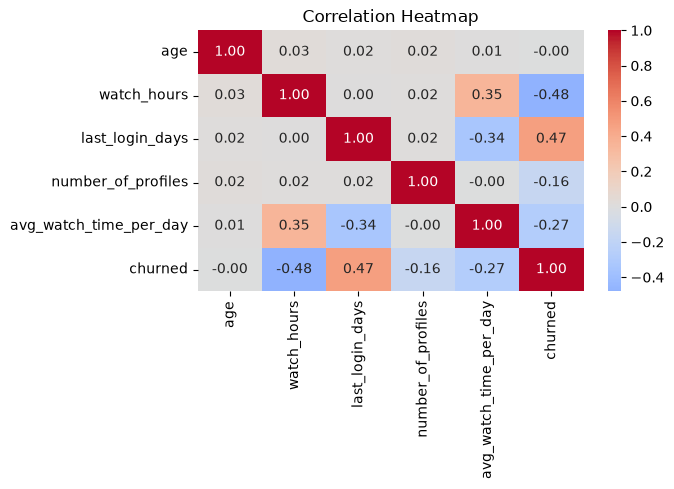

churned                   1.000000
last_login_days           0.471590
age                      -0.003515
number_of_profiles       -0.158614
avg_watch_time_per_day   -0.272958
watch_hours              -0.479916
Name: churned, dtype: float64


In [55]:

fig, ax = plt.subplots(figsize=(7, 5))
corr = df_model[numeric_cols + ["churned"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()
print(corr["churned"].sort_values(ascending=False))


### 12e. Churn Rate by Key Numeric Drivers

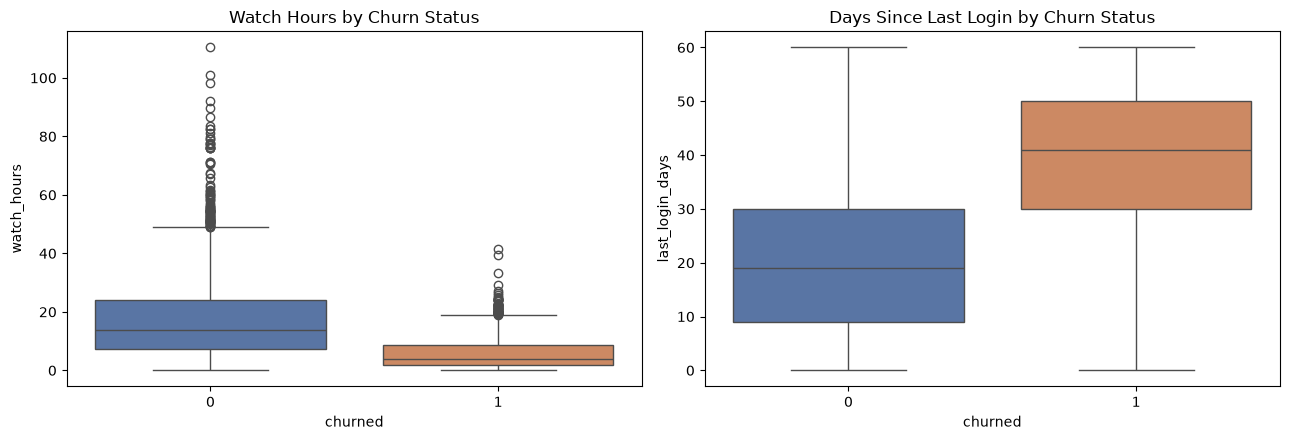

In [59]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x="churned", y="watch_hours", data=df_model, ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Watch Hours by Churn Status")
sns.boxplot(x="churned", y="last_login_days", data=df_model, ax=axes[1], palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Days Since Last Login by Churn Status")
plt.tight_layout()
plt.show()


### 12f. Churn Rate by Categorical Features

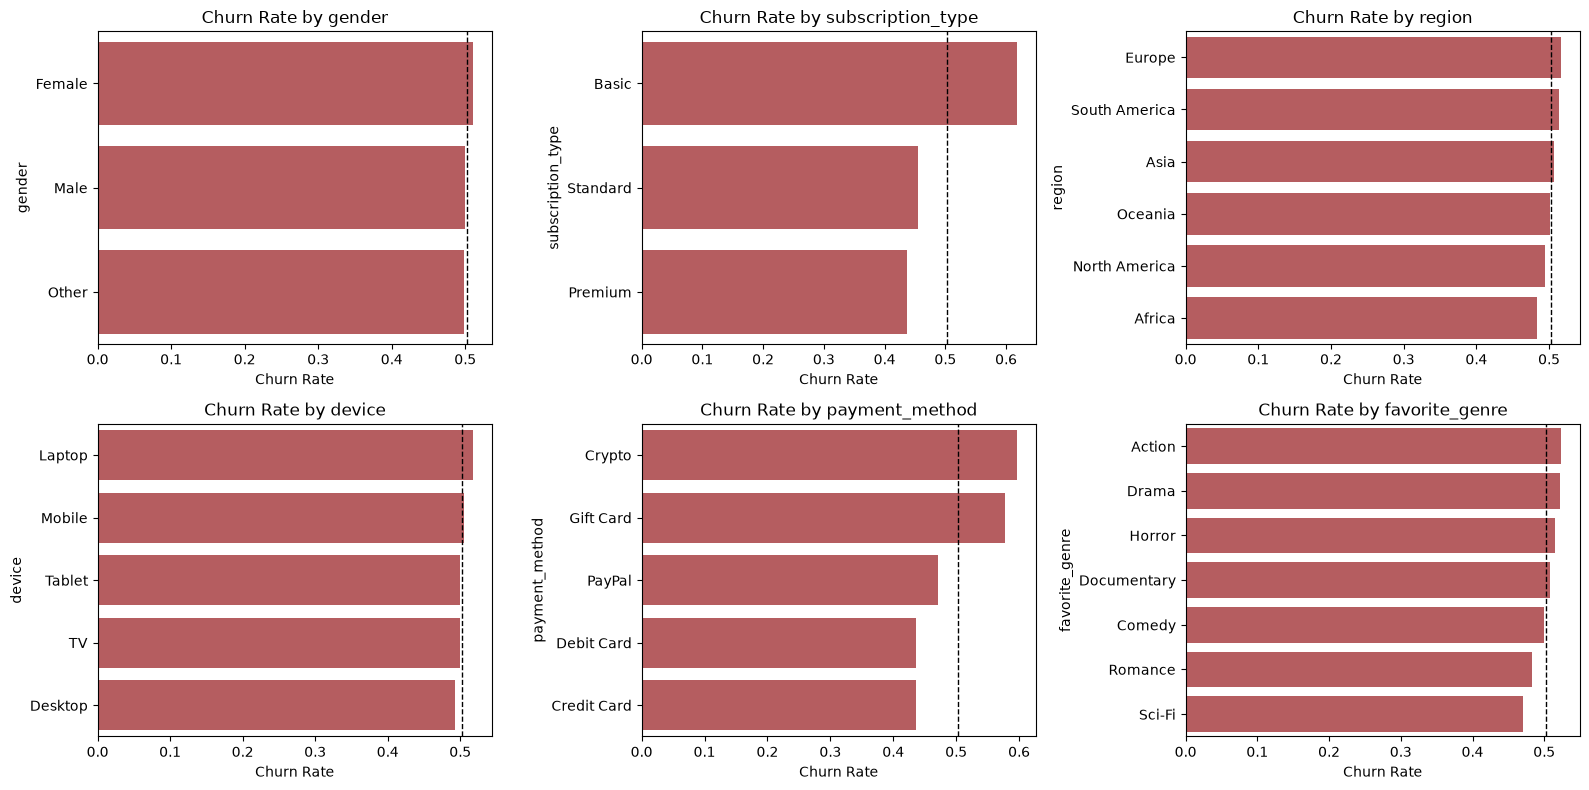

--- gender ---
gender
Female    0.511
Male      0.500
Other     0.498
Name: churned, dtype: float64

--- subscription_type ---
subscription_type
Basic       0.618
Standard    0.454
Premium     0.437
Name: churned, dtype: float64

--- region ---
region
Europe           0.517
South America    0.514
Asia             0.507
Oceania          0.501
North America    0.495
Africa           0.483
Name: churned, dtype: float64

--- device ---
device
Laptop     0.518
Mobile     0.505
Tablet     0.500
TV         0.499
Desktop    0.492
Name: churned, dtype: float64

--- payment_method ---
payment_method
Crypto         0.597
Gift Card      0.578
PayPal         0.471
Debit Card     0.437
Credit Card    0.436
Name: churned, dtype: float64

--- favorite_genre ---
favorite_genre
Action         0.524
Drama          0.523
Horror         0.515
Documentary    0.508
Comedy         0.499
Romance        0.483
Sci-Fi         0.471
Name: churned, dtype: float64



In [62]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, categorical_cols):
    rates = df_model.groupby(col)["churned"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color="#C44E52")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("Churn Rate")
    ax.axvline(df_model["churned"].mean(), color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df_model.groupby(col)["churned"].mean().sort_values(ascending=False).round(3))
    print()


### 12g. Number of Profiles vs Churn

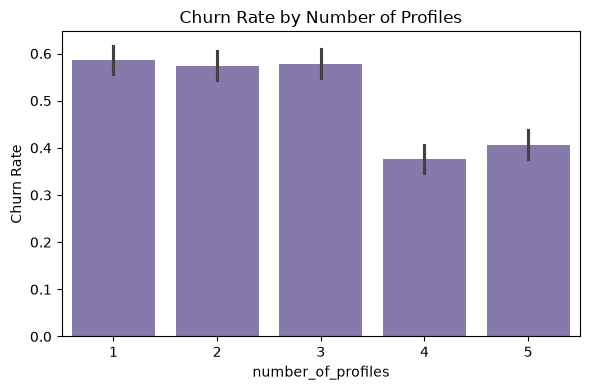

number_of_profiles
1    0.586
2    0.574
3    0.578
4    0.375
5    0.406
Name: churned, dtype: float64

Correlation (number_of_profiles, churned): -0.159


In [66]:

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x="number_of_profiles", y="churned", data=df_model, ax=ax, color="#8172B2")
ax.set_title("Churn Rate by Number of Profiles")
ax.set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()
print(df_model.groupby("number_of_profiles")["churned"].mean().round(3))
print()
print("Correlation (number_of_profiles, churned):", round(df_model["number_of_profiles"].corr(df_model["churned"]), 3))


## 7. Skewness Analysis

In [71]:

skew_vals = df_model[numeric_cols].skew().sort_values(ascending=False)
print(skew_vals)


avg_watch_time_per_day    15.834680
watch_hours                2.259195
age                        0.006334
number_of_profiles        -0.016895
last_login_days           -0.025977
dtype: float64


## 8. Outlier Detection

In [75]:

def iqr_outlier_report(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return lower, upper, n_out, round(n_out / len(series) * 100, 2)

for col in numeric_cols:
    lower, upper, n_out, pct = iqr_outlier_report(df_model[col])
    print(f"{col:28s} lower={lower:8.2f}  upper={upper:8.2f}  n_outliers={n_out:4d} ({pct}%)")


age                          lower=  -12.00  upper=  100.00  n_outliers=   0 (0.0%)
watch_hours                  lower=  -15.70  upper=   35.07  n_outliers= 238 (4.76%)
last_login_days              lower=  -30.00  upper=   90.00  n_outliers=   0 (0.0%)
number_of_profiles           lower=   -1.00  upper=    7.00  n_outliers=   0 (0.0%)
avg_watch_time_per_day       lower=   -0.81  upper=    1.64  n_outliers= 549 (10.98%)


In [77]:

print("Rows where avg_watch_time_per_day > 24 (physically impossible for a daily average):")
suspicious = df_model[df_model["avg_watch_time_per_day"] > 24]
print(suspicious[["watch_hours", "last_login_days", "avg_watch_time_per_day"]])


Rows where avg_watch_time_per_day > 24 (physically impossible for a daily average):
      watch_hours  last_login_days  avg_watch_time_per_day
647         25.15                0                   25.15
1219        52.80                0                   52.80
2017        98.42                0                   98.42
2564        34.53                0                   34.53
3641        28.66                0                   28.66
4078        32.81                0                   32.81
4285        54.53                1                   27.27
4792        32.88                0                   32.88
4805        29.55                0                   29.55
4845        26.98                0                   26.98


## 9. Outlier Handling Decision

In [80]:

cap_value = df_model["avg_watch_time_per_day"].quantile(0.99)
before_corr = df_model["avg_watch_time_per_day"].corr(df_model["churned"])
after_corr = df_model["avg_watch_time_per_day"].clip(upper=cap_value).corr(df_model["churned"])
print(f"99th percentile cap value: {cap_value:.2f}")
print(f"Correlation with churn BEFORE capping: {before_corr:.4f}")
print(f"Correlation with churn AFTER capping:  {after_corr:.4f}")

df_model["avg_watch_time_per_day"] = df_model["avg_watch_time_per_day"].clip(upper=cap_value)


99th percentile cap value: 10.92
Correlation with churn BEFORE capping: -0.2730
Correlation with churn AFTER capping:  -0.4012


## 10. Feature Engineering

We only add features with a clear business rationale, and we check each one actually correlates with churn before keeping it (not just "more columns = better").

In [ ]:

df_model["engagement_ratio"] = df_model["watch_hours"] / (df_model["last_login_days"] + 1)
df_model["watch_per_profile"] = df_model["watch_hours"] / df_model["number_of_profiles"]
df_model["is_inactive_30"] = (df_model["last_login_days"] > 30).astype(int)
new_features = ["engagement_ratio", "watch_per_profile", "is_inactive_30"]
numeric_cols = numeric_cols + new_features

print(df_model[new_features + ["churned"]].corr()["churned"])


engagement_ratio    -0.272968
watch_per_profile   -0.317080
is_inactive_30       0.489721
churned              1.000000
Name: churned, dtype: float64


Churn rate, active (<=30 days) vs inactive (>30 days) customers:
is_inactive_30
0    0.261
1    0.751
Name: churned, dtype: float64


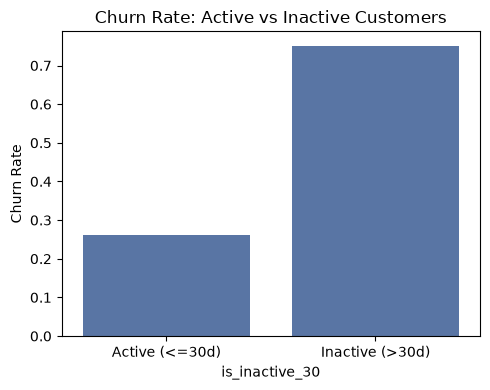

In [85]:

churn_by_inactive = df_model.groupby("is_inactive_30")["churned"].mean()
print("Churn rate, active (<=30 days) vs inactive (>30 days) customers:")
print(churn_by_inactive.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=churn_by_inactive.index, y=churn_by_inactive.values, ax=ax, color="#4C72B0")
ax.set_xticklabels(["Active (<=30d)", "Inactive (>30d)"])
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate: Active vs Inactive Customers")
plt.tight_layout()
plt.show()


### 10a. Engineered-Feature Redundancy Check

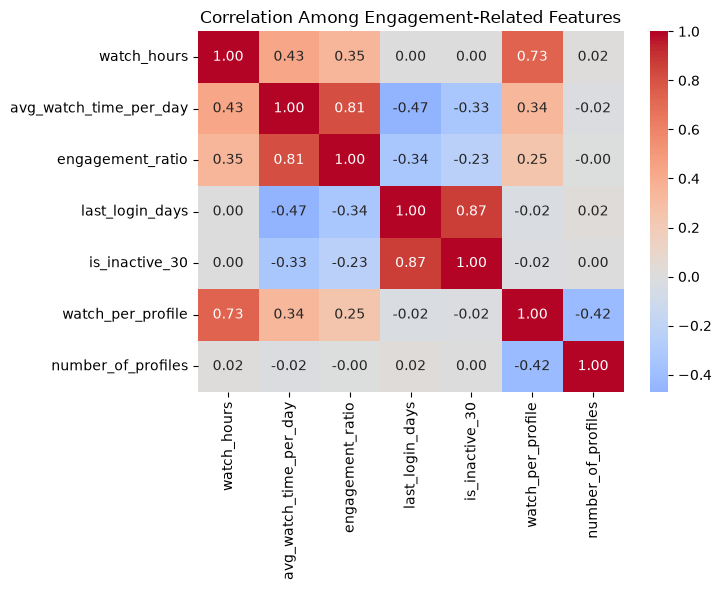

In [89]:

redundancy_cols = ["watch_hours", "avg_watch_time_per_day", "engagement_ratio",
                    "last_login_days", "is_inactive_30", "watch_per_profile", "number_of_profiles"]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(df_model[redundancy_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Among Engagement-Related Features")
plt.tight_layout()
plt.show()


## 11. Class Imbalance Analysis

In [93]:

print(df_model["churned"].value_counts())
print(df_model["churned"].value_counts(normalize=True).round(3))


churned
1    2515
0    2485
Name: count, dtype: int64
churned
1    0.503
0    0.497
Name: proportion, dtype: float64


## 11a. Data Leakage Check



In [97]:

print("All available columns:", df_model.columns.tolist())
print()
print("No date/timestamp/snapshot column exists in this dataset, so the measurement window for")
print("last_login_days relative to the churn event cannot be verified from the data alone.")


All available columns: ['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre', 'engagement_ratio', 'watch_per_profile', 'is_inactive_30']

No date/timestamp/snapshot column exists in this dataset, so the measurement window for
last_login_days relative to the churn event cannot be verified from the data alone.


In [100]:

churned_but_active = ((df_model["churned"] == 1) & (df_model["last_login_days"] <= 30)).sum()
retained_but_inactive = ((df_model["churned"] == 0) & (df_model["last_login_days"] > 30)).sum()
print(f"Churned customers who were NOT flagged inactive (last_login_days <= 30): {churned_but_active} / {(df_model['churned']==1).sum()}")
print(f"Retained customers who WERE flagged inactive (last_login_days > 30):    {retained_but_inactive} / {(df_model['churned']==0).sum()}")
print()

from sklearn.metrics import roc_auc_score as _auc
single_feature_auc = {
    "engagement_ratio (alone)": _auc(df_model["churned"], -df_model["engagement_ratio"]),
    "watch_hours (alone)": _auc(df_model["churned"], -df_model["watch_hours"]),
    "last_login_days (alone)": _auc(df_model["churned"], df_model["last_login_days"]),
    "is_inactive_30 (alone)": _auc(df_model["churned"], df_model["is_inactive_30"]),
}
for name, val in single_feature_auc.items():
    print(f"{name:32s} ROC-AUC using ONLY this feature: {val:.4f}")


Churned customers who were NOT flagged inactive (last_login_days <= 30): 661 / 2515
Retained customers who WERE flagged inactive (last_login_days > 30):    615 / 2485

engagement_ratio (alone)         ROC-AUC using ONLY this feature: 0.9237
watch_hours (alone)              ROC-AUC using ONLY this feature: 0.8125
last_login_days (alone)          ROC-AUC using ONLY this feature: 0.7721
is_inactive_30 (alone)           ROC-AUC using ONLY this feature: 0.7448


## 12. Train / Test Split

In [104]:

X = df_model.drop(columns=["churned"])
y = df_model["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Train shape: (4000, 14)  Test shape: (1000, 14)
Train churn rate: 0.503  Test churn rate: 0.503


The test set is now set aside and will only be touched **once**, for final evaluation in Section 15. All tuning and model selection below uses cross-validation on the training set only.

## 13. Preprocessing



In [108]:

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

preprocessor_linear = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scale", StandardScaler()),
    ]), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])


Numeric columns: ['age', 'watch_hours', 'last_login_days', 'number_of_profiles', 'avg_watch_time_per_day', 'engagement_ratio', 'watch_per_profile', 'is_inactive_30']
Categorical columns: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']


## 14. Model Training -- Baseline Comparison


In [ ]:

if XGBOOST_AVAILABLE:
    boosted_model = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    )
    boosted_name = "XGBoost"
else:
    boosted_model = HistGradientBoostingClassifier(max_iter=200, max_depth=4, random_state=RANDOM_STATE)
    boosted_name = "XGBoost (fallback: HistGradientBoosting)"

baseline_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), preprocessor_linear),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), preprocessor_tree),
    "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), preprocessor_tree),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_tree),
    boosted_name: (boosted_model, preprocessor_tree),
}

baseline_pipelines = {}
for name, (model, prep) in baseline_models.items():
    pipe = Pipeline([("preprocessor", prep), ("model", model)])
    pipe.fit(X_train, y_train)
    baseline_pipelines[name] = pipe
print("Trained models:", list(baseline_pipelines.keys()))


Trained models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 15. Cross-Validation (Training Set Only)

In [114]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, (model, prep) in baseline_models.items():
    pipe = Pipeline([("preprocessor", prep), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:35s}  ROC-AUC = {scores.mean():.4f}  (+/- {scores.std():.4f})")


Logistic Regression                  ROC-AUC = 0.9794  (+/- 0.0012)
Decision Tree                        ROC-AUC = 0.9730  (+/- 0.0051)
Random Forest                        ROC-AUC = 0.9974  (+/- 0.0018)
Gradient Boosting                    ROC-AUC = 0.9991  (+/- 0.0006)
XGBoost                              ROC-AUC = 0.9996  (+/- 0.0004)


## 16. Baseline Model Comparison (multiple metrics)

In [117]:

from sklearn.model_selection import cross_val_predict

def full_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

comparison_rows = {}
for name, (model, prep) in baseline_models.items():
    pipe = Pipeline([("preprocessor", prep), ("model", model)])
    proba = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    pred = (proba >= 0.5).astype(int)
    comparison_rows[name] = full_metrics(y_train, pred, proba)

comparison_df = pd.DataFrame(comparison_rows).T.sort_values("ROC-AUC", ascending=False)
comparison_df.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Balanced Accuracy
XGBoost,0.9928,0.9960,0.9896,0.9928,0.9995,0.9995,0.9928
Gradient Boosting,0.9895,0.9940,0.9851,0.9895,0.9991,0.9992,0.9895
Random Forest,0.9772,0.9849,0.9697,0.9772,0.9975,0.9978,0.9773
Logistic Regression,0.9155,0.9123,0.9205,0.9164,0.9795,0.9804,0.9155
Decision Tree,0.9730,0.9704,0.9761,0.9732,0.9730,0.9592,0.9730


**Note on R² (requested for educational purposes):** R² is a *regression* metric (proportion of variance explained) and is not an appropriate way to select or evaluate a classifier -- a model can have a "poor" R² on 0/1 labels while being an excellent classifier, because R² penalizes any probability that isn't exactly 0 or 1. We compute it once below purely so this claim isn't just asserted, but it is **never** used to pick or judge a model.

In [119]:

for name, (model, prep) in baseline_models.items():
    pipe = Pipeline([("preprocessor", prep), ("model", model)])
    proba = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    r2 = r2_score(y_train, proba)
    print(f"{name:35s}  R^2 (probabilities vs 0/1 labels) = {r2:.4f}  <- NOT used for model selection")


Logistic Regression                  R^2 (probabilities vs 0/1 labels) = 0.7664  <- NOT used for model selection
Decision Tree                        R^2 (probabilities vs 0/1 labels) = 0.8920  <- NOT used for model selection
Random Forest                        R^2 (probabilities vs 0/1 labels) = 0.8973  <- NOT used for model selection
Gradient Boosting                    R^2 (probabilities vs 0/1 labels) = 0.9484  <- NOT used for model selection
XGBoost                              R^2 (probabilities vs 0/1 labels) = 0.9763  <- NOT used for model selection


## 17. Hyperparameter Tuning


In [122]:

tuned_pipelines = {}
tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression: C controls regularization strength ---
lr_pipe = Pipeline([("preprocessor", preprocessor_linear), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
lr_grid = {"model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l2"], "model__solver": ["lbfgs"]}
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring="roc_auc", cv=tuning_cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
tuned_pipelines["Logistic Regression"] = lr_search.best_estimator_
print("Logistic Regression best params:", lr_search.best_params_, " CV ROC-AUC:", round(lr_search.best_score_, 4))


Logistic Regression best params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}  CV ROC-AUC: 0.9803


In [126]:

# --- Decision Tree: depth/leaf/split params control overfitting ---
dt_pipe = Pipeline([("preprocessor", preprocessor_tree), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))])
dt_grid = {
    "model__max_depth": [4, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"],
}
dt_search = RandomizedSearchCV(dt_pipe, dt_grid, n_iter=20, scoring="roc_auc", cv=tuning_cv, random_state=RANDOM_STATE, n_jobs=-1)
dt_search.fit(X_train, y_train)
tuned_pipelines["Decision Tree"] = dt_search.best_estimator_
print("Decision Tree best params:", dt_search.best_params_, " CV ROC-AUC:", round(dt_search.best_score_, 4))


Decision Tree best params: {'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 8, 'model__criterion': 'entropy'}  CV ROC-AUC: 0.99


In [128]:

# --- Random Forest: n_estimators/depth/leaf/features control the ensemble ---
rf_pipe = Pipeline([("preprocessor", preprocessor_tree), ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [6, 10, 14, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(rf_pipe, rf_grid, n_iter=15, scoring="roc_auc", cv=tuning_cv, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
tuned_pipelines["Random Forest"] = rf_search.best_estimator_
print("Random Forest best params:", rf_search.best_params_, " CV ROC-AUC:", round(rf_search.best_score_, 4))


Random Forest best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 14}  CV ROC-AUC: 0.9971


In [ ]:

gb_pipe = Pipeline([("preprocessor", preprocessor_tree), ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}
gb_search = RandomizedSearchCV(gb_pipe, gb_grid, n_iter=15, scoring="roc_auc", cv=tuning_cv, random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train, y_train)
tuned_pipelines["Gradient Boosting"] = gb_search.best_estimator_
print("Gradient Boosting best params:", gb_search.best_params_, " CV ROC-AUC:", round(gb_search.best_score_, 4))


Gradient Boosting best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.2}  CV ROC-AUC: 0.9997


In [ ]:

if XGBOOST_AVAILABLE:
    xgb_pipe = Pipeline([("preprocessor", preprocessor_tree), ("model", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
    xgb_grid = {
        "model__n_estimators": [150, 250, 350],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.03, 0.1, 0.2],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__gamma": [0, 0.1, 0.3],
    }
else:
    xgb_pipe = Pipeline([("preprocessor", preprocessor_tree), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])
    xgb_grid = {
        "model__max_iter": [150, 250, 350],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.03, 0.1, 0.2],
        "model__l2_regularization": [0, 0.1, 0.5],
    }

xgb_search = RandomizedSearchCV(xgb_pipe, xgb_grid, n_iter=15, scoring="roc_auc", cv=tuning_cv, random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)
tuned_pipelines[boosted_name] = xgb_search.best_estimator_
print(f"{boosted_name} best params:", xgb_search.best_params_, " CV ROC-AUC:", round(xgb_search.best_score_, 4))


XGBoost best params: {'model__subsample': 1.0, 'model__n_estimators': 250, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.85}  CV ROC-AUC: 0.9998


## 18. Model Improvement: Baseline vs Tuned

In [137]:

improvement_rows = []
for name in baseline_models:
    baseline_scores = cross_val_score(
        Pipeline([("preprocessor", baseline_models[name][1]), ("model", baseline_models[name][0])]),
        X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    tuned_scores = cross_val_score(tuned_pipelines[name], X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    improvement_rows.append({
        "Model": name,
        "Baseline ROC-AUC": baseline_scores.mean(),
        "Tuned ROC-AUC": tuned_scores.mean(),
        "Improvement": tuned_scores.mean() - baseline_scores.mean(),
    })

improvement_df = pd.DataFrame(improvement_rows).sort_values("Tuned ROC-AUC", ascending=False)
improvement_df.round(4)


,Model,Baseline ROC-AUC,Tuned ROC-AUC,Improvement
3,Gradient Boosting,0.9991,0.9998,0.0007
4,XGBoost,0.9996,0.9997,0.0001
2,Random Forest,0.9974,0.9971,-0.0003
1,Decision Tree,0.9730,0.9917,0.0188
0,Logistic Regression,0.9794,0.9794,0.0000


## 18a. Performance Robustness & Leakage Sensitivity Analysis



In [141]:

best_algo_name = improvement_df.iloc[0]["Model"]
best_model_template = tuned_pipelines[best_algo_name].named_steps["model"]
print("Robustness experiments use this algorithm + tuned hyperparameters:", best_algo_name)
print(best_model_template)


Robustness experiments use this algorithm + tuned hyperparameters: Gradient Boosting
GradientBoostingClassifier(learning_rate=0.2, max_depth=2, min_samples_split=10,
                           n_estimators=300, random_state=42)


In [ ]:

def run_robustness_experiment(drop_cols, label):
    keep_numeric = [c for c in numeric_cols if c not in drop_cols]
    keep_categorical = [c for c in categorical_cols if c not in drop_cols]

    prep = ColumnTransformer(transformers=[
        ("num", "passthrough", keep_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), keep_categorical),
    ])
    from sklearn.base import clone
    pipe = Pipeline([("preprocessor", prep), ("model", clone(best_model_template))])

    X_tr = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
    proba = cross_val_predict(pipe, X_tr, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = full_metrics(y_train, pred, proba)
    metrics["Experiment"] = label
    metrics["Features Removed"] = ", ".join(drop_cols) if drop_cols else "(none - baseline)"
    return metrics

experiments = [
    ([], "1. Baseline (all current features)"),
    (["is_inactive_30"], "2. Remove is_inactive_30"),
    (["last_login_days"], "3. Remove last_login_days"),
    (["engagement_ratio"], "4. Remove engagement_ratio"),
    (["avg_watch_time_per_day"], "5. Remove avg_watch_time_per_day (most redundant, 0.81 corr with engagement_ratio)"),
    (["last_login_days", "is_inactive_30", "engagement_ratio", "avg_watch_time_per_day"],
     "6. BONUS: remove entire inactivity/engagement-ratio cluster"),
]

robustness_rows = []
for drop_cols, label in experiments:
    robustness_rows.append(run_robustness_experiment(drop_cols, label))

robustness_df = pd.DataFrame(robustness_rows).set_index("Experiment")
robustness_df = robustness_df[["Features Removed", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Balanced Accuracy"]]
robustness_df.round(4)


,Features Removed,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Balanced Accuracy
Experiment,,,,,,,,
1. Baseline (all current features),(none - baseline),0.9965,0.9995,0.9935,0.9965,0.9998,0.9998,0.9965
2. Remove is_inactive_30,is_inactive_30,0.9965,0.9995,0.9935,0.9965,0.9998,0.9998,0.9965
3. Remove last_login_days,last_login_days,0.9945,0.9945,0.9945,0.9945,0.9996,0.9997,0.9945
4. Remove engagement_ratio,engagement_ratio,0.9970,0.9990,0.9950,0.9970,0.9998,0.9999,0.9970
"5. Remove avg_watch_time_per_day (most redundant, 0.81 corr with engagement_ratio)",avg_watch_time_per_day,0.9965,0.9995,0.9935,0.9965,0.9998,0.9998,0.9965
6. BONUS: remove entire inactivity/engagement-ratio cluster,"last_login_days, is_inactive_30, engagement_ra...",0.7562,0.7594,0.7545,0.7569,0.8624,0.8624,0.7563


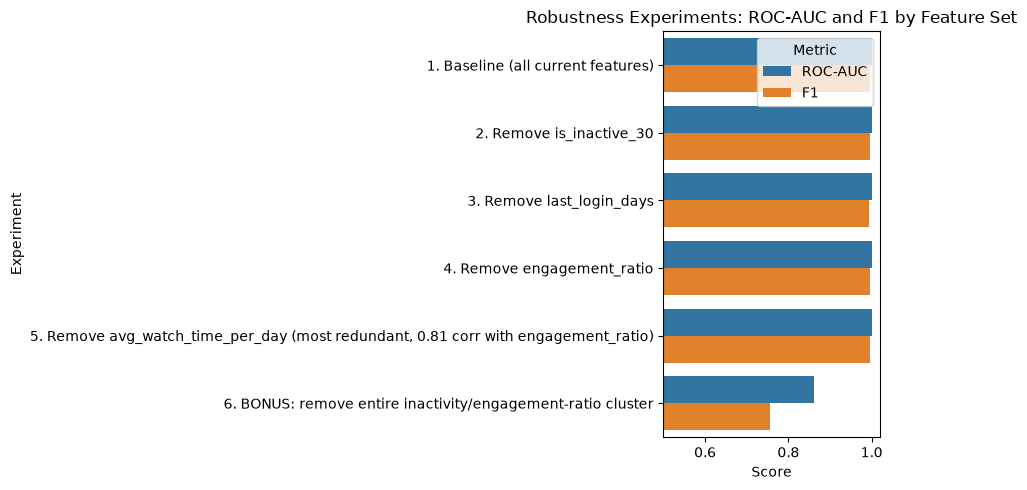

In [144]:

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = robustness_df[["ROC-AUC", "F1"]].reset_index()
plot_df_melt = plot_df.melt(id_vars="Experiment", var_name="Metric", value_name="Score")
sns.barplot(data=plot_df_melt, y="Experiment", x="Score", hue="Metric", ax=ax)
ax.set_xlim(0.5, 1.02)
ax.set_title("Robustness Experiments: ROC-AUC and F1 by Feature Set")
plt.tight_layout()
plt.show()


## 19. Threshold Optimization



Best model by CV ROC-AUC: Gradient Boosting
Threshold that maximizes F1 on CV predictions: 0.353
At that threshold -> Precision: 0.999, Recall: 0.997, F1: 0.998


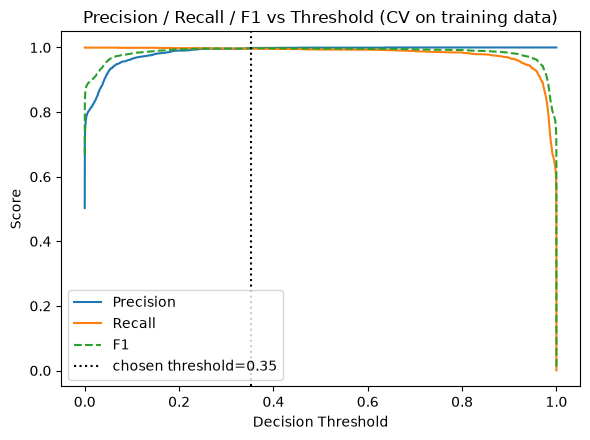

In [147]:

best_model_name = improvement_df.iloc[0]["Model"]
best_pipeline_pretune = tuned_pipelines[best_model_name]
print("Best model by CV ROC-AUC:", best_model_name)

cv_proba_train = cross_val_predict(best_pipeline_pretune, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, cv_proba_train)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_threshold = thresholds[best_idx]
print(f"Threshold that maximizes F1 on CV predictions: {best_threshold:.3f}")
print(f"At that threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.plot(thresholds, f1s[:-1], label="F1", linestyle="--")
ax.axvline(best_threshold, color="black", linestyle=":", label=f"chosen threshold={best_threshold:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold (CV on training data)")
ax.legend()
plt.tight_layout()
plt.show()


## 20. Final Evaluation on the Held-Out Test Set

In [150]:

final_pipeline = tuned_pipelines[best_model_name]
final_pipeline.fit(X_train, y_train)  # refit on full training set (already done by search, but explicit for clarity)

test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_tuned = (test_proba >= best_threshold).astype(int)

print(f"=== {best_model_name} on TEST SET (default 0.50 threshold) ===")
for k, v in full_metrics(y_test, test_pred_default, test_proba).items():
    print(f"{k:20s}: {v:.4f}")

print()
print(f"=== {best_model_name} on TEST SET (tuned threshold = {best_threshold:.3f}) ===")
for k, v in full_metrics(y_test, test_pred_tuned, test_proba).items():
    print(f"{k:20s}: {v:.4f}")


=== Gradient Boosting on TEST SET (default 0.50 threshold) ===
Accuracy            : 0.9960
Precision           : 0.9980
Recall              : 0.9940
F1                  : 0.9960
ROC-AUC             : 0.9991
PR-AUC              : 0.9989
Balanced Accuracy   : 0.9960

=== Gradient Boosting on TEST SET (tuned threshold = 0.353) ===
Accuracy            : 0.9970
Precision           : 0.9960
Recall              : 0.9980
F1                  : 0.9970
ROC-AUC             : 0.9991
PR-AUC              : 0.9989
Balanced Accuracy   : 0.9970


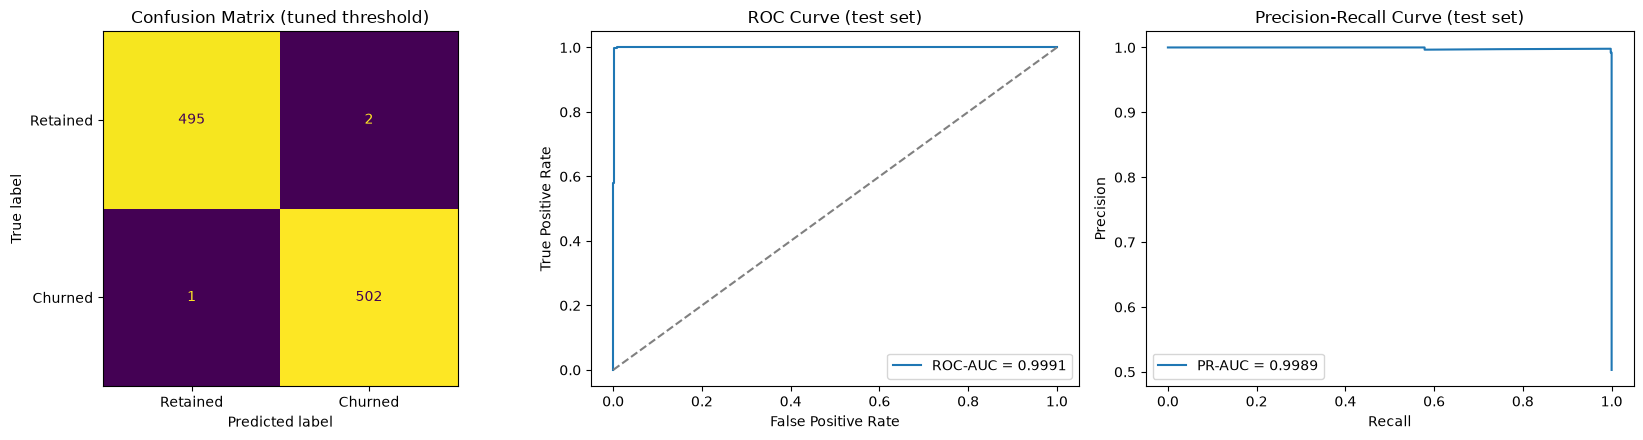

In [152]:

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_tuned), display_labels=["Retained", "Churned"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (tuned threshold)")

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_proba):.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[2].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, test_proba):.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve (test set)")
axes[2].legend()

plt.tight_layout()
plt.show()


In [157]:

test_r2 = r2_score(y_test, test_proba)
print(f"R^2 (probabilities vs 0/1 labels) on test set: {test_r2:.4f}  <- reported for completeness only, NOT the selection metric")


R^2 (probabilities vs 0/1 labels) on test set: 0.9840  <- reported for completeness only, NOT the selection metric


## 21. SHAP Explainability

In [ ]:

ohe = final_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
ohe_feature_names = list(ohe.get_feature_names_out(categorical_cols))
all_feature_names = numeric_cols + ohe_feature_names
print(f"Total features after preprocessing: {len(all_feature_names)}")


Total features after preprocessing: 37


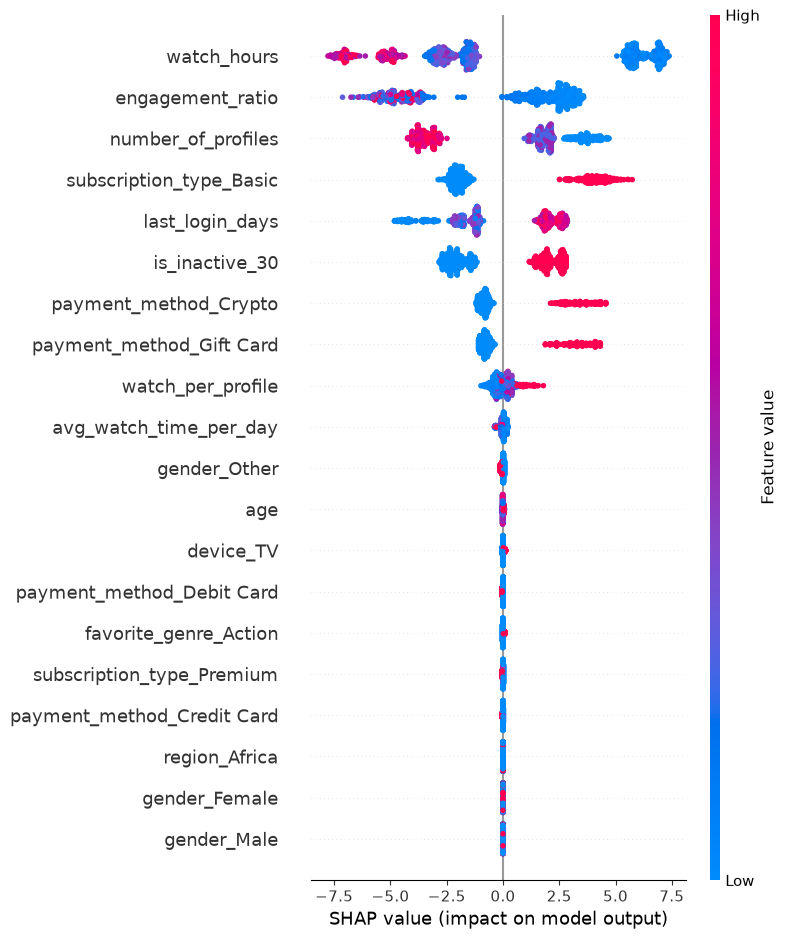

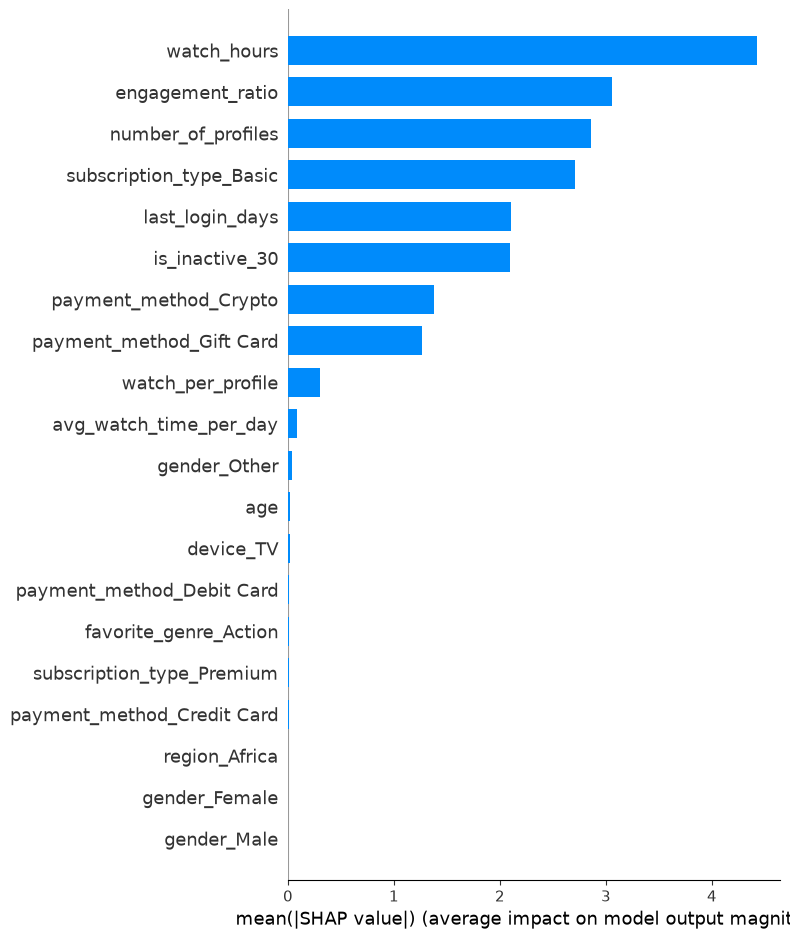

In [ ]:

X_test_transformed = final_pipeline.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
    shap_values = explainer.shap_values(X_test_transformed_df)
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    shap.summary_plot(shap_values_plot, X_test_transformed_df, show=False)
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values_plot, X_test_transformed_df, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()
else:
    print("shap is not installed in this environment (see requirements.txt to install it for a full run).")
    print("Falling back to permutation importance on the test set as an executable, real-data substitute below.")


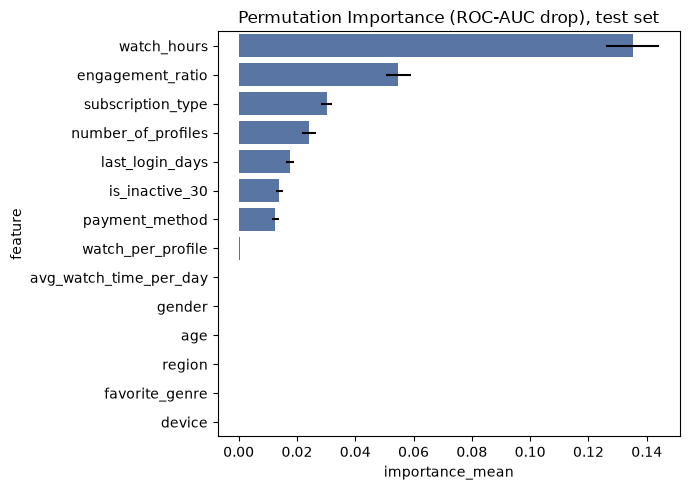

,feature,importance_mean,importance_std
3,watch_hours,0.1352,0.0090
11,engagement_ratio,0.0547,0.0043
2,subscription_type,0.0302,0.0018
8,number_of_profiles,0.0240,0.0024
4,last_login_days,0.0177,0.0014
13,is_inactive_30,0.0140,0.0013
7,payment_method,0.0126,0.0012
12,watch_per_profile,0.0005,0.0001
9,avg_watch_time_per_day,0.0000,0.0000
1,gender,0.0000,0.0000


In [166]:

perm_result = permutation_importance(
    final_pipeline, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x="importance_mean", y="feature", data=perm_df, ax=ax, color="#4C72B0",
            xerr=perm_df["importance_std"])
ax.set_title("Permutation Importance (ROC-AUC drop), test set")
plt.tight_layout()
plt.show()
perm_df.round(4)


### 22. Native Feature Importance (model's own `feature_importances_`)

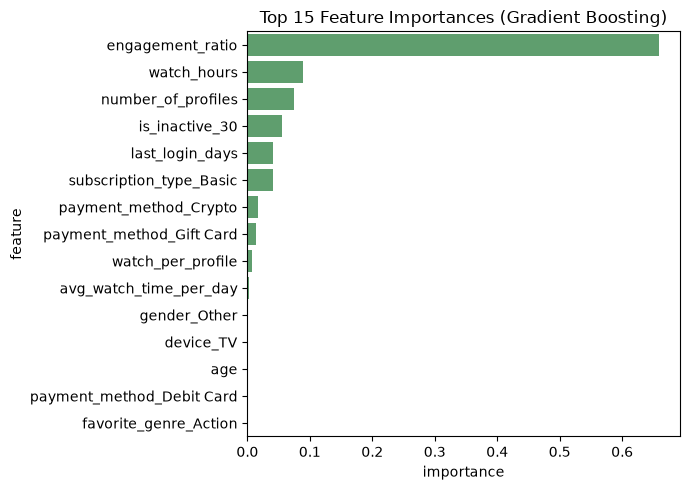

                      feature  importance
5            engagement_ratio    0.659587
1                 watch_hours    0.088334
3          number_of_profiles    0.074882
7              is_inactive_30    0.056143
2             last_login_days    0.041263
11    subscription_type_Basic    0.040603
26      payment_method_Crypto    0.016470
28   payment_method_Gift Card    0.013437
6           watch_per_profile    0.006680
4      avg_watch_time_per_day    0.002508
10               gender_Other    0.000037
23                  device_TV    0.000025
0                         age    0.000016
27  payment_method_Debit Card    0.000005
30      favorite_genre_Action    0.000005


In [170]:

model_step = final_pipeline.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    fi_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": model_step.feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(x="importance", y="feature", data=fi_df, ax=ax, color="#55A868")
    ax.set_title(f"Top 15 Feature Importances ({best_model_name})")
    plt.tight_layout()
    plt.show()
    print(fi_df)
else:
    print(f"{best_model_name} does not expose feature_importances_ directly (e.g. it's a linear model) -- rely on the permutation importance above instead.")


## 23. Final Model Selection


## 24. Save the Complete Model

In [ ]:

import os
os.makedirs("model_artifacts", exist_ok=True)

model_bundle = {
    "pipeline": final_pipeline,
    "threshold": float(best_threshold),
    "feature_columns": list(X.columns),
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "model_name": best_model_name,
}

joblib.dump(model_bundle, "churn_model.pkl")
print("Saved churn_model.pkl containing: fitted pipeline (preprocessing + model), decision threshold, and column metadata.")


Saved churn_model.pkl containing: fitted pipeline (preprocessing + model), decision threshold, and column metadata.


## 25. Reload and Test the Saved Model

In [184]:

reloaded_bundle = joblib.load("churn_model.pkl")
reloaded_pipeline = reloaded_bundle["pipeline"]
reloaded_threshold = reloaded_bundle["threshold"]

sample_customer = X_test.iloc[[0]]
print("Sample input:")
print(sample_customer.T)

proba = reloaded_pipeline.predict_proba(sample_customer)[0, 1]
pred = int(proba >= reloaded_threshold)
print()
print(f"Predicted churn probability: {proba:.3f}")
print(f"Predicted class (threshold={reloaded_threshold:.3f}): {'Churn' if pred == 1 else 'No Churn'}")
print(f"Actual label: {'Churn' if y_test.iloc[0] == 1 else 'No Churn'}")


Sample input:
                            1911
age                           67
gender                      Male
subscription_type       Standard
watch_hours                26.05
last_login_days               21
region                    Europe
device                        TV
payment_method            PayPal
number_of_profiles             4
avg_watch_time_per_day      1.18
favorite_genre             Drama
engagement_ratio        1.184091
watch_per_profile         6.5125
is_inactive_30                 0

Predicted churn probability: 0.000
Predicted class (threshold=0.353): No Churn
Actual label: No Churn
